# Notebook 01 — Dataset Overview and Corpus Profiling

## Objective

Profile **OpenAlex**, **Crossref**, and **Local repositories** independently before merging.
This establishes corpus size, temporal coverage, publication types, institutions, DOI quality,
and within-source duplicates — the foundation for missing-value handling and enrichment.

## Questions answered

1. How many records / columns does each source have?
2. What years are covered (especially 2016+)?
3. Which publication types dominate each source?
4. Which Sri Lankan institutions / repositories contribute most?
5. How complete is DOI coverage overall and by type / institute?
6. How many duplicate DOIs and titles exist within each source?
7. What is a reasonable unique-publication estimate per source?

## Column conventions used

| Source | DOI | Year | Type | Institution |
|--------|-----|------|------|-------------|
| OpenAlex | `doi` | `publication_year` | `type` | `sri_lankan_institutions` |
| Crossref | `DOI` | `publication_year` | `type` | `author_affiliation` |
| Local | `doi` | `publication_year` | `publication_type` | `source_institution_id` |

**Outputs:** `./outputs/notebook01/*.csv` + plots.


## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)


## 2. Configuration & data loading


In [2]:
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("./outputs/notebook01")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OA_PATH = DATA_DIR / "raw/open-alex/open_alex.csv"
CR_PATH = DATA_DIR / "processed/crossref_clean_2016_2026_enriched.csv"
LOCAL_PATH = DATA_DIR / "raw/open-alex/repositories_combined.csv"


def load_dataset(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, low_memory=False)


openalex_df = load_dataset(OA_PATH)
crossref_df = load_dataset(CR_PATH)
local_df = load_dataset(LOCAL_PATH)

# Keep Local records in the same study window as OpenAlex/Crossref
local_df["publication_year"] = pd.to_numeric(local_df["publication_year"], errors="coerce")
local_df = local_df[local_df["publication_year"] >= 2016].copy()

print(f"OpenAlex : {openalex_df.shape}")
print(f"Crossref : {crossref_df.shape}")
print(f"Local    : {local_df.shape}")
print("\nOpenAlex columns:", list(openalex_df.columns))
print("\nCrossref columns:", list(crossref_df.columns))
print("\nLocal columns:", list(local_df.columns))


OpenAlex : (73289, 34)
Crossref : (65946, 55)
Local    : (60812, 19)

OpenAlex columns: ['openalex_id', 'doi', 'title', 'publication_year', 'publication_date', 'type', 'cited_by_count', 'author_count', 'authors', 'sri_lankan_authors', 'institutions', 'sri_lankan_institutions', 'countries', 'source_name', 'publisher', 'is_oa', 'landing_page_url', 'pdf_url', 'referenced_works_count', 'concepts', 'topics', 'primary_topic', 'primary_field', 'primary_subfield', 'primary_domain', 'language', 'oa_status', 'license', 'source_type', 'issn_l', 'volume', 'issue', 'first_page', 'last_page']

Crossref columns: ['reference-count', 'publisher', 'issue', 'abstract', 'DOI', 'type', 'is-referenced-by-count', 'title', 'volume', 'container-title', 'URL', 'ISSN', 'issued.date-parts', 'published.date-parts', 'created.date-parts', 'page', 'event.name', 'event.location', 'event.start.date-parts', 'event.end.date-parts', 'language', 'article-number', 'publisher-location', 'event.acronym', 'group-title', 'subty

## 3. Helpers & column map


In [3]:
DATASETS = {
    "OpenAlex": openalex_df,
    "Crossref": crossref_df,
    "Local": local_df,
}

# Canonical field -> actual column name in each source
COLMAP = {
    "OpenAlex": {
        "doi": "doi",
        "title": "title",
        "year": "publication_year",
        "type": "type",
        "institution": "sri_lankan_institutions",
        "date": "publication_date",
        "authors": "authors",
        "publisher": "publisher",
        "venue": "source_name",
    },
    "Crossref": {
        "doi": "DOI",
        "title": "title",
        "year": "publication_year",
        "type": "type",
        "institution": "author_affiliation",
        "date": "issued.date-parts",
        "authors": "author_name",
        "publisher": "publisher",
        "venue": "container-title",
    },
    "Local": {
        "doi": "doi",
        "title": "title",
        "year": "publication_year",
        "type": "publication_type",
        "institution": "source_institution_id",
        "date": "publication_date",
        "authors": "authors",
        "publisher": "publisher",
        "venue": "journal",
    },
}

# Map raw publication types into a small shared vocabulary for cross-source plots
TYPE_MAP = {
    "article": "journal_article",
    "journal-article": "journal_article",
    "journal article": "journal_article",
    "research article": "journal_article",
    "conference-paper": "conference_paper",
    "proceedings-article": "conference_paper",
    "conference paper": "conference_paper",
    "conference-full-text": "conference_paper",
    "conference-abstract": "conference_abstract",
    "conference-extended-abstract": "conference_abstract",
    "book-chapter": "book_chapter",
    "book chapter": "book_chapter",
    "book": "book",
    "monograph": "book",
    "edited-book": "book",
    "reference-book": "book",
    "preprint": "preprint",
    "posted-content": "preprint",
    "review": "review",
    "dataset": "dataset",
    "thesis": "thesis",
    "dissertation": "thesis",
    "thesis-full-text": "thesis",
    "thesis-abstract": "thesis",
    "thesis abstract": "thesis",
    "report": "report",
    "editorial": "editorial",
    "erratum": "erratum",
    "peer-review": "peer_review",
    "other": "other",
}


def get_field(dataset_name: str, field: str):
    df = DATASETS[dataset_name]
    col = COLMAP.get(dataset_name, {}).get(field)
    if col is None or col not in df.columns:
        return None
    return df[col]


def normalize_title(s):
    if pd.isna(s):
        return None
    s = str(s).lower().strip()
    s = re.sub(r"[^a-z0-9\s]", "", s)
    s = re.sub(r"\s+", " ", s)
    return s if s else None


def normalize_doi(x):
    if pd.isna(x):
        return None
    x = str(x).lower().strip()
    for prefix in ("https://doi.org/", "http://doi.org/", "doi:"):
        x = x.replace(prefix, "")
    x = x.strip()
    return x if x and x not in {"nan", "none", "null"} else None


def canonical_type(x):
    if pd.isna(x):
        return "unknown"
    key = str(x).lower().strip().replace("_", "-")
    key = re.sub(r"\s+", " ", key)
    mapped = TYPE_MAP.get(key) or TYPE_MAP.get(key.replace(" ", "-"))
    return mapped if mapped else "other"


def save_csv(df_to_save: pd.DataFrame, filename: str):
    path = OUTPUT_DIR / filename
    df_to_save.to_csv(path, index=(df_to_save.index.name is not None))
    print(f"Saved -> {path}")
    return path


print("Canonical fields available:")
for name in DATASETS:
    available = [f for f, c in COLMAP[name].items() if c in DATASETS[name].columns]
    missing = [f for f, c in COLMAP[name].items() if c not in DATASETS[name].columns]
    print(f"  {name}: available={available}")
    if missing:
        print(f"           missing={missing}")


Canonical fields available:
  OpenAlex: available=['doi', 'title', 'year', 'type', 'institution', 'date', 'authors', 'publisher', 'venue']
  Crossref: available=['doi', 'title', 'year', 'type', 'institution', 'date', 'authors', 'publisher', 'venue']
  Local: available=['doi', 'title', 'year', 'type', 'institution', 'date', 'authors', 'publisher', 'venue']


## 4. Total records & column counts


In [4]:
records_summary = pd.DataFrame({
    "dataset": list(DATASETS.keys()),
    "total_records": [len(df) for df in DATASETS.values()],
    "total_columns": [df.shape[1] for df in DATASETS.values()],
})
save_csv(records_summary, "01_total_records_summary.csv")
records_summary


Saved -> outputs/notebook01/01_total_records_summary.csv


,dataset,total_records,total_columns
0,OpenAlex,73289,34
1,Crossref,65946,55
2,Local,60812,19


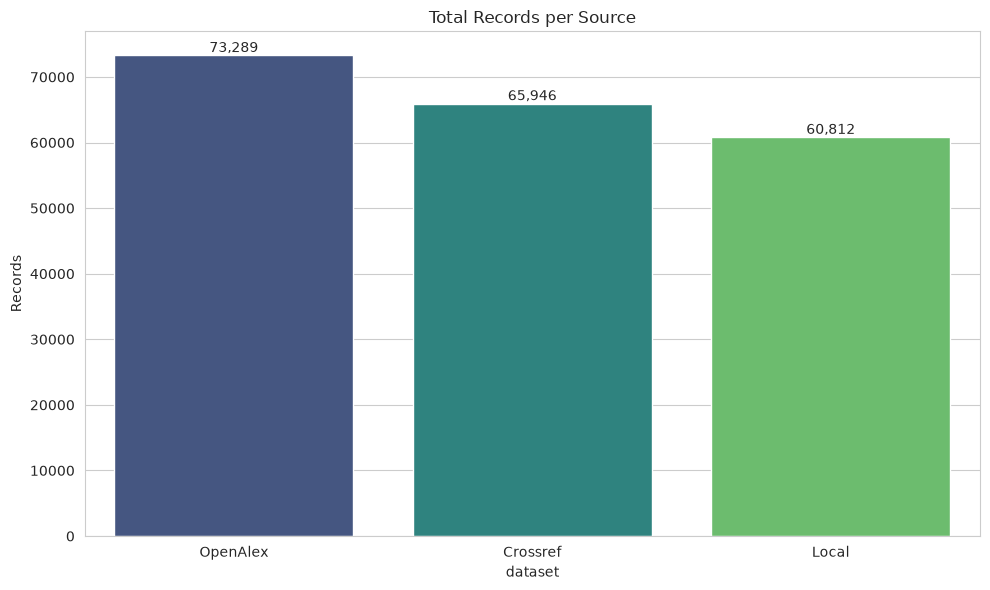

In [5]:
fig, ax = plt.subplots()
sns.barplot(data=records_summary, x="dataset", y="total_records", ax=ax, palette="viridis")
ax.set_title("Total Records per Source")
ax.set_ylabel("Records")
for i, v in enumerate(records_summary["total_records"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 5. Publication year distribution


In [6]:
def year_distribution(dataset_name):
    years = get_field(dataset_name, "year")
    if years is None:
        return pd.Series(dtype=int)
    years_numeric = pd.to_numeric(years, errors="coerce")
    return years_numeric.dropna().astype(int).value_counts().sort_index()


year_dist = {name: year_distribution(name) for name in DATASETS}
year_dist_df = pd.DataFrame(year_dist).fillna(0).astype(int)
year_dist_df.index.name = "publication_year"
save_csv(year_dist_df, "02_year_distribution.csv")
year_dist_df.tail(15)


Saved -> outputs/notebook01/02_year_distribution.csv


,OpenAlex,Crossref,Local
publication_year,,,
2016,3684,3170,5478
2017,4034,3634,5915
2018,4790,4159,5635
2019,5368,4670,6321
2020,6547,5897,5618
2021,8629,8077,7001
2022,7826,7510,6238
2023,7902,7347,5915
2024,7451,7057,5675


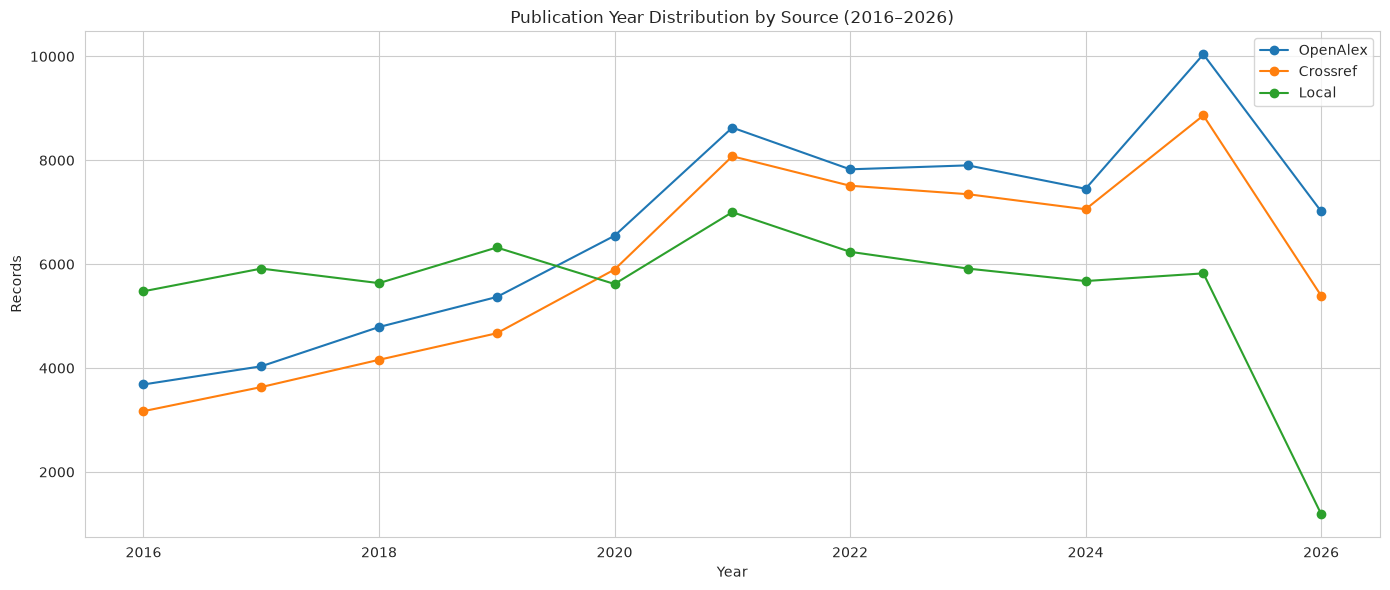

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
for name in DATASETS:
    if name in year_dist_df.columns:
        series = year_dist_df[name]
        series = series[(series.index >= 2016) & (series.index <= 2026)]
        ax.plot(series.index, series.values, marker="o", label=name)
ax.set_title("Publication Year Distribution by Source (2016–2026)")
ax.set_xlabel("Year")
ax.set_ylabel("Records")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Year range & 2016+ coverage


In [8]:
def year_stats(dataset_name):
    years = get_field(dataset_name, "year")
    total = len(DATASETS[dataset_name])
    if years is None:
        return {
            "min_year": None,
            "max_year": None,
            "records_2016_plus": None,
            "records_2016_plus_pct": None,
        }
    years_numeric = pd.to_numeric(years, errors="coerce")
    valid = years_numeric.dropna()
    plus = (valid >= 2016).sum()
    return {
        "min_year": int(valid.min()) if len(valid) else None,
        "max_year": int(valid.max()) if len(valid) else None,
        "records_2016_plus": int(plus),
        "records_2016_plus_pct": round(100 * plus / total, 2) if total else None,
    }


year_stats_df = pd.DataFrame({name: year_stats(name) for name in DATASETS}).T
year_stats_df.index.name = "dataset"
save_csv(year_stats_df, "03_year_range_and_2016plus.csv")
year_stats_df


Saved -> outputs/notebook01/03_year_range_and_2016plus.csv


,min_year,max_year,records_2016_plus,records_2016_plus_pct
dataset,,,,
OpenAlex,2016.0,2026.0,73289.0,100.00
Crossref,2016.0,2027.0,65779.0,99.75
Local,2016.0,2099.0,60812.0,100.00


## 7. Publication type distribution

Raw type vocabularies differ across sources (OpenAlex `article` vs Crossref `journal-article`
vs Local `Article` / `journal-article`). We report both **raw** and **canonical** types.


In [9]:
def type_distribution(dataset_name, top_n=25, canonical=False):
    types = get_field(dataset_name, "type")
    if types is None:
        return pd.Series(dtype=int)
    cleaned = types.fillna("MISSING").astype(str).str.strip().replace("", "MISSING")
    if canonical:
        cleaned = cleaned.map(canonical_type)
    return cleaned.value_counts().head(top_n)


type_rows = []
for name in DATASETS:
    for mode, flag in [("raw", False), ("canonical", True)]:
        series = type_distribution(name, canonical=flag)
        for t, cnt in series.items():
            type_rows.append({
                "dataset": name,
                "type_mode": mode,
                "publication_type": t,
                "count": int(cnt),
                "pct": round(100 * cnt / len(DATASETS[name]), 2),
            })

type_dist_df = pd.DataFrame(type_rows)
save_csv(type_dist_df, "04_publication_type_distribution.csv")
type_dist_df[type_dist_df["type_mode"] == "canonical"].head(30)


Saved -> outputs/notebook01/04_publication_type_distribution.csv


,dataset,type_mode,publication_type,count,pct
23,OpenAlex,canonical,journal_article,47202,64.41
24,OpenAlex,canonical,conference_paper,11636,15.88
25,OpenAlex,canonical,preprint,4896,6.68
26,OpenAlex,canonical,book_chapter,3050,4.16
27,OpenAlex,canonical,report,1554,2.12
28,OpenAlex,canonical,other,1220,1.66
29,OpenAlex,canonical,conference_abstract,1118,1.53
30,OpenAlex,canonical,review,964,1.32
31,OpenAlex,canonical,dataset,792,1.08
32,OpenAlex,canonical,peer_review,231,0.32


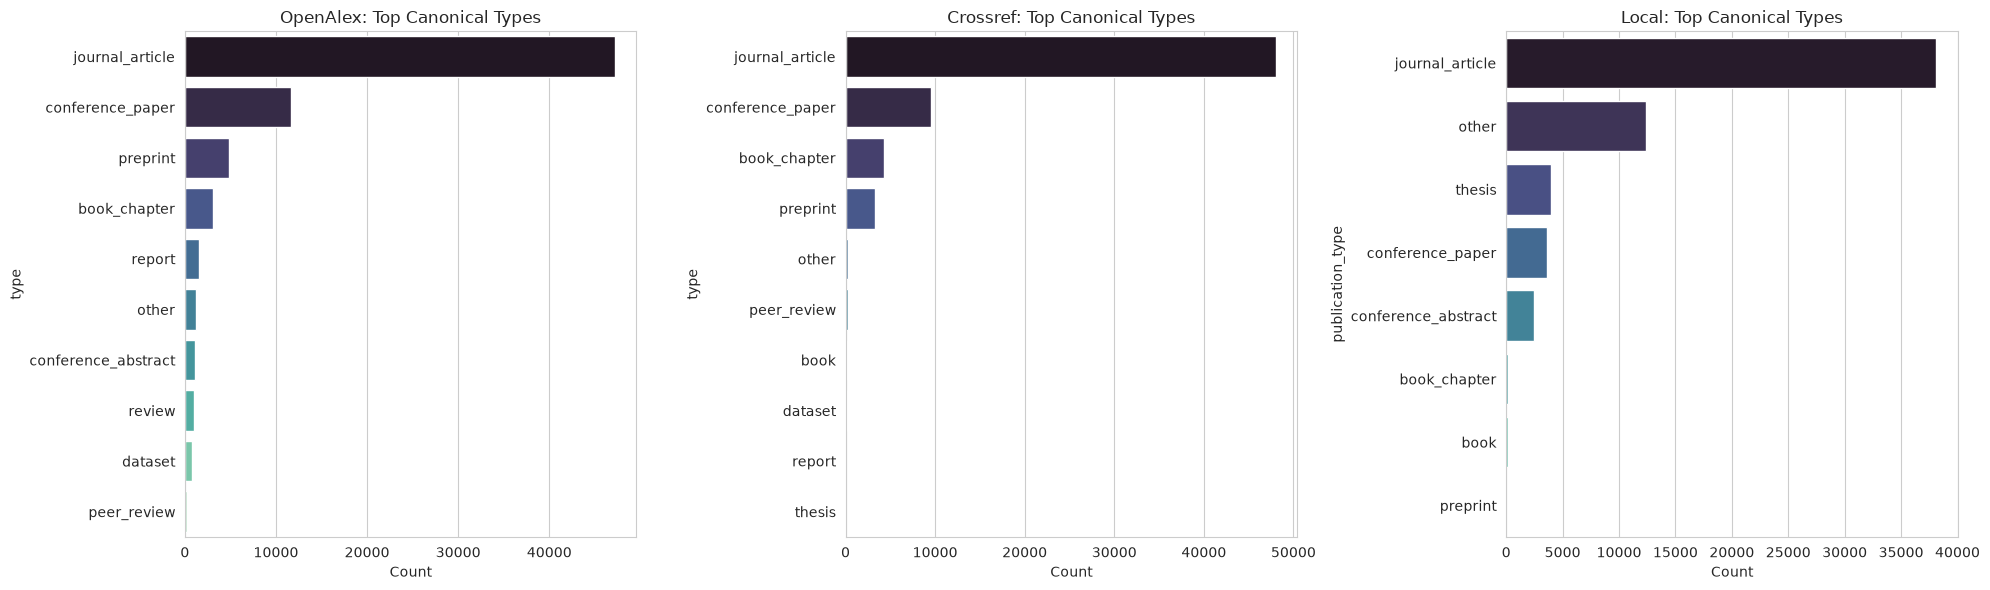

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, name in zip(axes, DATASETS):
    series = type_distribution(name, top_n=10, canonical=True)
    if not series.empty:
        sns.barplot(x=series.values, y=series.index, ax=ax, palette="mako")
    ax.set_title(f"{name}: Top Canonical Types")
    ax.set_xlabel("Count")
plt.tight_layout()
plt.show()


## 8. Institution / repository distribution

- **Local:** `source_institution_id` (sljol, ruh, uom, seu, uwu, sliit, pdn, cmb, busl, nsf, sltc)
- **OpenAlex:** `sri_lankan_institutions` (may list multiple institutions separated by `;` or `|`)
- **Crossref:** `author_affiliation` (free-text; noisier — use for presence, not clean institute ranking)


In [11]:
def institution_distribution(dataset_name, top_n=25):
    inst = get_field(dataset_name, "institution")
    if inst is None:
        return pd.Series(dtype=int)
    s = inst.dropna().astype(str)
    exploded = s.str.split(r"[;|]").explode().str.strip()
    exploded = exploded[(exploded != "") & (~exploded.str.lower().isin(["nan", "none", "null"]))]
    return exploded.value_counts().head(top_n)


inst_rows = []
inst_dist = {}
for name in DATASETS:
    series = institution_distribution(name, top_n=30)
    inst_dist[name] = series
    for inst, cnt in series.items():
        inst_rows.append({"dataset": name, "institution": inst, "count": int(cnt)})

inst_dist_df = pd.DataFrame(inst_rows)
save_csv(inst_dist_df, "05_institution_distribution.csv")
inst_dist_df.head(40)


Saved -> outputs/notebook01/05_institution_distribution.csv


,dataset,institution,count
0,OpenAlex,University of Colombo,9611
1,OpenAlex,University of Peradeniya,9601
2,OpenAlex,University of Sri Jayewardenepura,8173
3,OpenAlex,University of Moratuwa,7355
4,OpenAlex,University of Kelaniya,5780
5,OpenAlex,Sri Lanka Institute of Information Technology,4018
6,OpenAlex,University of Ruhuna,3853
7,OpenAlex,Department of Archaeology,3734
8,OpenAlex,University of Jaffna,3262
9,OpenAlex,National Hospital of Sri Lanka,2312


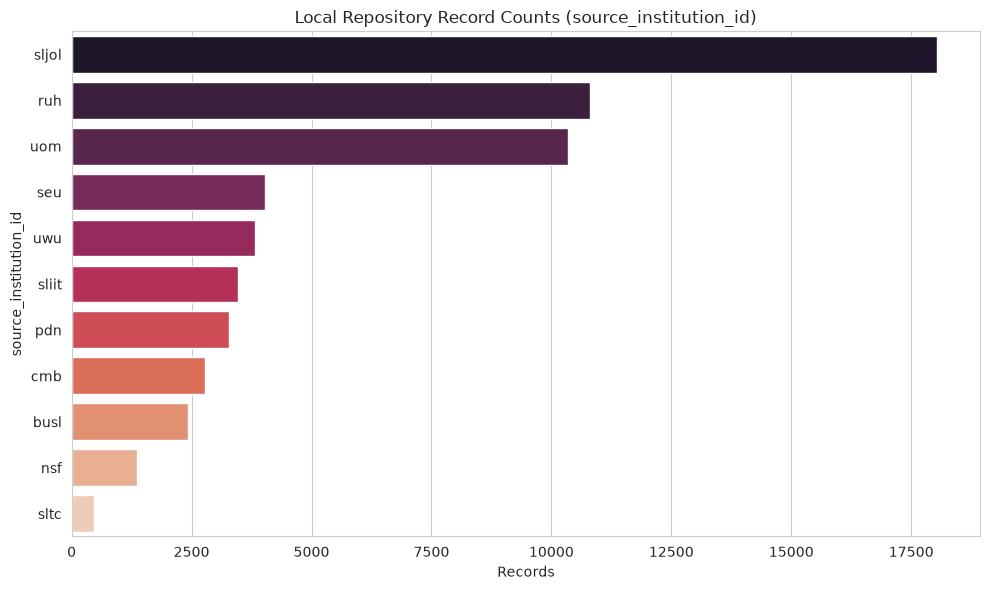

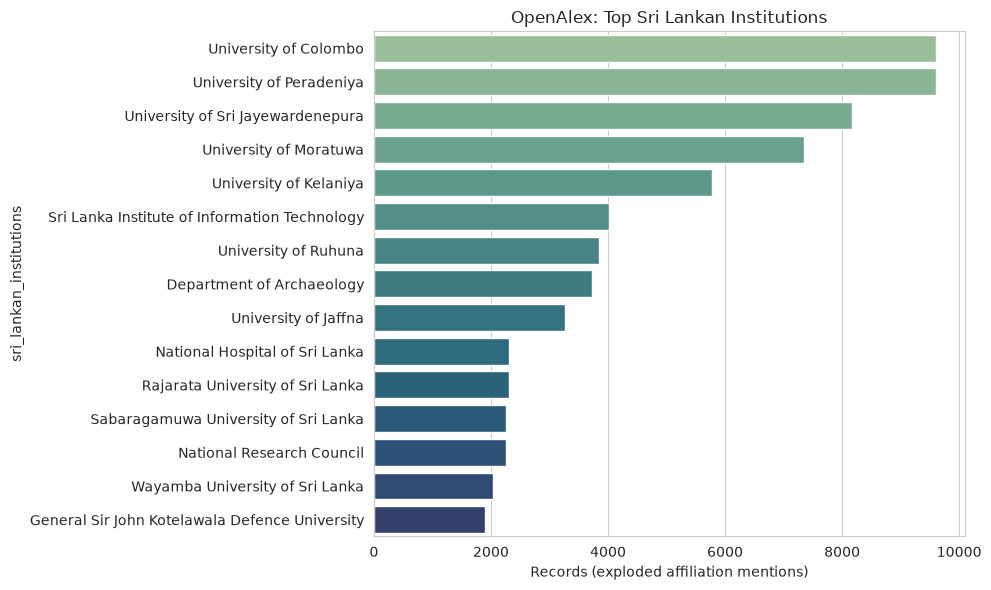

In [12]:
# Local repositories — clean categorical breakdown
local_inst = inst_dist.get("Local", pd.Series(dtype=int))
if not local_inst.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=local_inst.values, y=local_inst.index, ax=ax, palette="rocket")
    ax.set_title("Local Repository Record Counts (source_institution_id)")
    ax.set_xlabel("Records")
    plt.tight_layout()
    plt.show()

# OpenAlex top Sri Lankan institutions
oa_inst = inst_dist.get("OpenAlex", pd.Series(dtype=int)).head(15)
if not oa_inst.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=oa_inst.values, y=oa_inst.index, ax=ax, palette="crest")
    ax.set_title("OpenAlex: Top Sri Lankan Institutions")
    ax.set_xlabel("Records (exploded affiliation mentions)")
    plt.tight_layout()
    plt.show()


## 9. DOI availability (overall)


In [13]:
def doi_availability(dataset_name):
    doi = get_field(dataset_name, "doi")
    total = len(DATASETS[dataset_name])
    if doi is None:
        return {"has_doi_column": False, "total": total, "non_missing": 0, "coverage_pct": 0.0}
    doi_norm = doi.apply(normalize_doi)
    non_missing = int(doi_norm.notna().sum())
    return {
        "has_doi_column": True,
        "total": total,
        "non_missing": non_missing,
        "coverage_pct": round(100 * non_missing / total, 2) if total else 0.0,
    }


doi_avail_df = pd.DataFrame({name: doi_availability(name) for name in DATASETS}).T
doi_avail_df.index.name = "dataset"
save_csv(doi_avail_df, "06_doi_availability.csv")
doi_avail_df


Saved -> outputs/notebook01/06_doi_availability.csv


,has_doi_column,total,non_missing,coverage_pct
dataset,,,,
OpenAlex,True,73289,71399,97.42
Crossref,True,65946,65946,100.0
Local,True,60812,25406,41.78


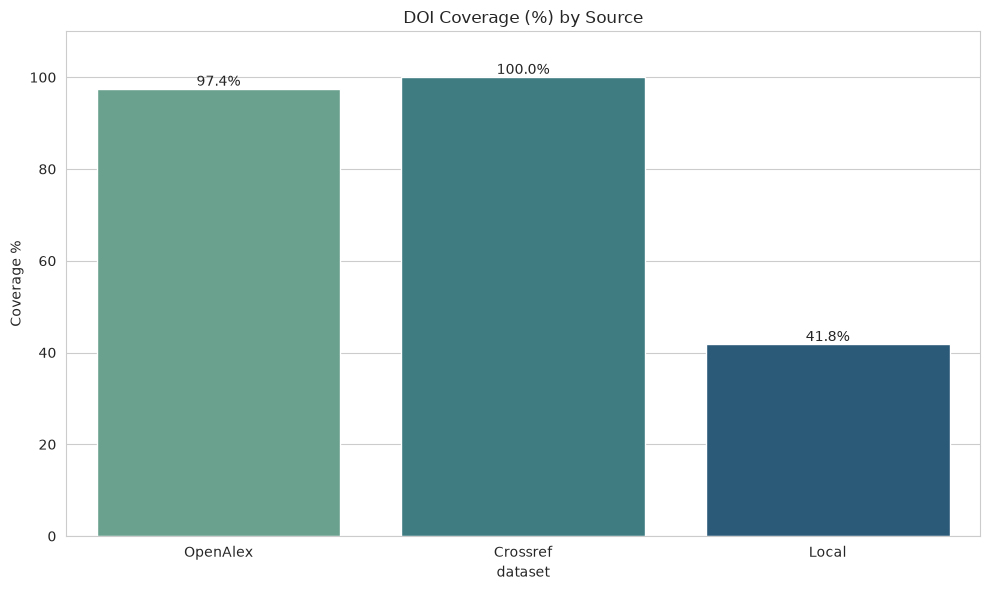

In [14]:
fig, ax = plt.subplots()
plot_df = doi_avail_df.reset_index()
plot_df["coverage_pct"] = pd.to_numeric(plot_df["coverage_pct"], errors="coerce")
sns.barplot(data=plot_df, x="dataset", y="coverage_pct", ax=ax, palette="crest")
ax.set_title("DOI Coverage (%) by Source")
ax.set_ylabel("Coverage %")
ax.set_ylim(0, 110)
for i, v in enumerate(plot_df["coverage_pct"]):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 10. DOI coverage by publication type

Shows which work types lack DOIs — critical for deciding when title-based matching
is needed instead of DOI join.


In [15]:
def doi_by_type(dataset_name):
    df = DATASETS[dataset_name]
    doi = get_field(dataset_name, "doi")
    typ = get_field(dataset_name, "type")
    if doi is None or typ is None:
        return pd.DataFrame()
    tmp = pd.DataFrame({
        "canonical_type": typ.map(canonical_type),
        "has_doi": doi.apply(normalize_doi).notna(),
    })
    out = (
        tmp.groupby("canonical_type")
        .agg(records=("has_doi", "size"), with_doi=("has_doi", "sum"))
        .reset_index()
    )
    out["doi_coverage_pct"] = (100 * out["with_doi"] / out["records"]).round(2)
    out["dataset"] = dataset_name
    return out.sort_values("records", ascending=False)


doi_type_df = pd.concat([doi_by_type(n) for n in DATASETS], ignore_index=True)
save_csv(doi_type_df, "06b_doi_coverage_by_type.csv")
doi_type_df


Saved -> outputs/notebook01/06b_doi_coverage_by_type.csv


,canonical_type,records,with_doi,doi_coverage_pct,dataset
0,journal_article,47202,46280,98.05,OpenAlex
1,conference_paper,11636,11226,96.48,OpenAlex
2,preprint,4896,4450,90.89,OpenAlex
3,book_chapter,3050,3023,99.11,OpenAlex
4,report,1554,1538,98.97,OpenAlex
5,other,1220,1197,98.11,OpenAlex
6,conference_abstract,1118,1113,99.55,OpenAlex
7,review,964,942,97.72,OpenAlex
8,dataset,792,792,100.00,OpenAlex
9,peer_review,231,231,100.00,OpenAlex


## 11. DOI coverage by institution (OpenAlex + Local)

Institute-wise DOI gaps tell us which repositories / universities need title matching
or Crossref enrichment most.


In [16]:
def doi_by_institution(dataset_name, top_n=20):
    doi = get_field(dataset_name, "doi")
    inst = get_field(dataset_name, "institution")
    if doi is None or inst is None:
        return pd.DataFrame()

    tmp = pd.DataFrame({
        "institution_raw": inst.astype(str),
        "has_doi": doi.apply(normalize_doi).notna(),
    })
    tmp = tmp[~tmp["institution_raw"].str.lower().isin(["nan", "none", "null", ""])]

    rows = []
    for inst_raw, has_doi in zip(tmp["institution_raw"], tmp["has_doi"]):
        for part in re.split(r"[;|]", inst_raw):
            part = part.strip()
            if part and part.lower() not in {"nan", "none", "null"}:
                rows.append({"institution": part, "has_doi": has_doi})

    exploded = pd.DataFrame(rows)
    if exploded.empty:
        return pd.DataFrame()

    out = (
        exploded.groupby("institution")
        .agg(records=("has_doi", "size"), with_doi=("has_doi", "sum"))
        .reset_index()
    )
    out["doi_coverage_pct"] = (100 * out["with_doi"] / out["records"]).round(2)
    out["dataset"] = dataset_name
    return out.sort_values("records", ascending=False).head(top_n)


doi_inst_df = pd.concat(
    [doi_by_institution("OpenAlex", 20), doi_by_institution("Local", 20)],
    ignore_index=True,
)
save_csv(doi_inst_df, "06c_doi_coverage_by_institution.csv")
doi_inst_df


Saved -> outputs/notebook01/06c_doi_coverage_by_institution.csv


,institution,records,with_doi,doi_coverage_pct,dataset
0,University of Colombo,9611,9416,97.97,OpenAlex
1,University of Peradeniya,9601,9476,98.70,OpenAlex
2,University of Sri Jayewardenepura,8173,7748,94.80,OpenAlex
3,University of Moratuwa,7355,7255,98.64,OpenAlex
4,University of Kelaniya,5780,5639,97.56,OpenAlex
5,Sri Lanka Institute of Information Technology,4018,3966,98.71,OpenAlex
6,University of Ruhuna,3853,3768,97.79,OpenAlex
7,Department of Archaeology,3734,3687,98.74,OpenAlex
8,University of Jaffna,3262,3151,96.60,OpenAlex
9,National Hospital of Sri Lanka,2312,2283,98.75,OpenAlex


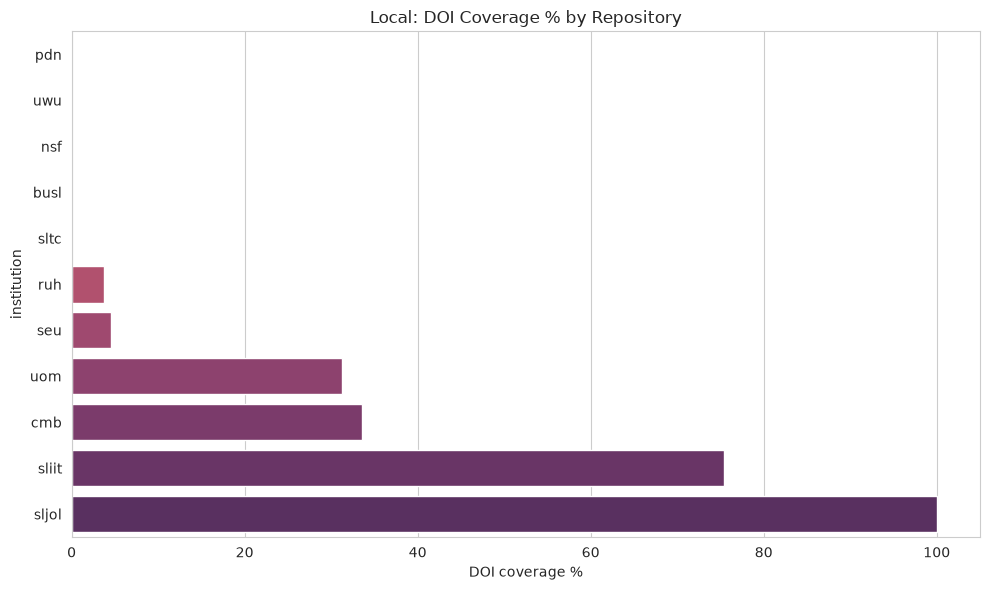

In [17]:
# Plot Local DOI coverage by repository
local_doi_inst = doi_inst_df[doi_inst_df["dataset"] == "Local"].sort_values("doi_coverage_pct")
if not local_doi_inst.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=local_doi_inst, x="doi_coverage_pct", y="institution", ax=ax, palette="flare")
    ax.set_title("Local: DOI Coverage % by Repository")
    ax.set_xlabel("DOI coverage %")
    plt.tight_layout()
    plt.show()


## 12. Duplicate DOI count (within source)


In [18]:
def duplicate_doi_stats(dataset_name):
    doi = get_field(dataset_name, "doi")
    if doi is None:
        return {
            "records_with_doi": 0,
            "unique_doi": 0,
            "duplicate_doi_rows": 0,
            "duplicate_doi_values": 0,
        }
    doi_clean = doi.apply(normalize_doi).dropna()
    n = len(doi_clean)
    unique = doi_clean.nunique()
    vc = doi_clean.value_counts()
    dup_values = int((vc > 1).sum())
    dup_rows = int(vc[vc > 1].sum())
    return {
        "records_with_doi": n,
        "unique_doi": unique,
        "duplicate_doi_rows": dup_rows,
        "duplicate_doi_values": dup_values,
    }


dup_doi_df = pd.DataFrame({name: duplicate_doi_stats(name) for name in DATASETS}).T
dup_doi_df.index.name = "dataset"
save_csv(dup_doi_df, "07_duplicate_doi_stats.csv")
dup_doi_df


Saved -> outputs/notebook01/07_duplicate_doi_stats.csv


,records_with_doi,unique_doi,duplicate_doi_rows,duplicate_doi_values
dataset,,,,
OpenAlex,71399,71367,64,32
Crossref,65946,65946,0,0
Local,25406,24710,1341,645


## 13. Duplicate title count (within source)


In [19]:
def duplicate_title_stats(dataset_name):
    titles = get_field(dataset_name, "title")
    if titles is None:
        return {
            "records_with_title": 0,
            "unique_titles": 0,
            "duplicate_title_rows": 0,
            "duplicate_title_values": 0,
        }
    norm = titles.dropna().apply(normalize_title)
    norm = norm[norm.notna()]
    n = len(norm)
    unique = norm.nunique()
    vc = norm.value_counts()
    dup_values = int((vc > 1).sum())
    dup_rows = int(vc[vc > 1].sum())
    return {
        "records_with_title": n,
        "unique_titles": unique,
        "duplicate_title_rows": dup_rows,
        "duplicate_title_values": dup_values,
    }


dup_title_df = pd.DataFrame({name: duplicate_title_stats(name) for name in DATASETS}).T
dup_title_df.index.name = "dataset"
save_csv(dup_title_df, "08_duplicate_title_stats.csv")
dup_title_df


Saved -> outputs/notebook01/08_duplicate_title_stats.csv


,records_with_title,unique_titles,duplicate_title_rows,duplicate_title_values
dataset,,,,
OpenAlex,73200,69587,6489,2876
Crossref,65861,64053,3133,1325
Local,60801,53320,11626,4145


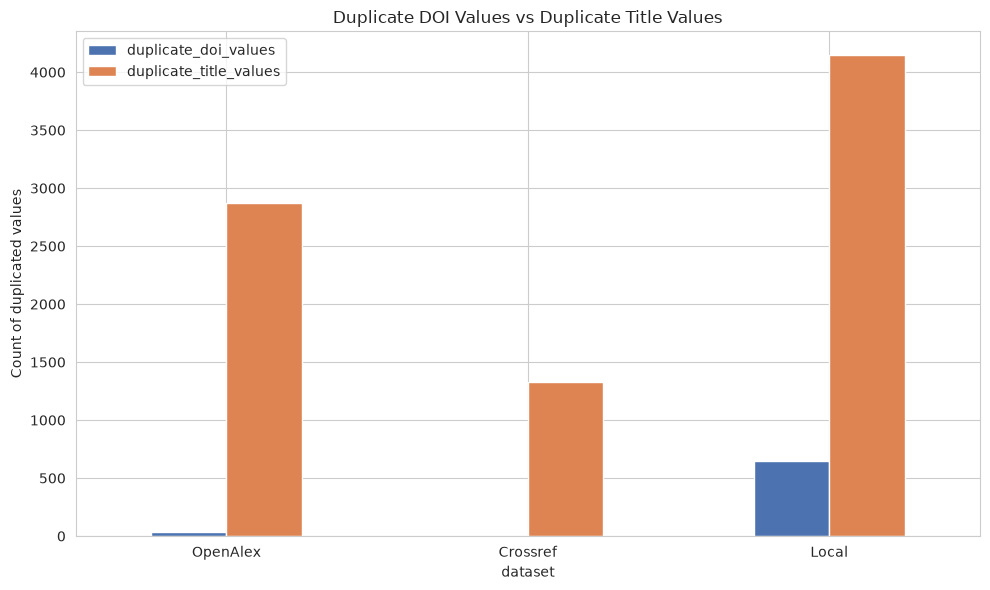

In [20]:
fig, ax = plt.subplots()
compare_df = pd.DataFrame({
    "duplicate_doi_values": dup_doi_df["duplicate_doi_values"].astype(float),
    "duplicate_title_values": dup_title_df["duplicate_title_values"].astype(float),
})
compare_df.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Duplicate DOI Values vs Duplicate Title Values")
ax.set_ylabel("Count of duplicated values")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 14. Unique publication count estimation

- If DOI coverage ≥ 50%: `unique DOIs + records without DOI`
- Else: fall back to unique normalized titles (conservative for Local)


In [21]:
def estimate_unique_publications(dataset_name):
    total = len(DATASETS[dataset_name])
    doi_stats = duplicate_doi_stats(dataset_name)
    title_stats = duplicate_title_stats(dataset_name)
    doi_coverage = doi_stats["records_with_doi"] / total if total else 0

    if doi_coverage >= 0.5:
        without_doi = total - doi_stats["records_with_doi"]
        estimated = doi_stats["unique_doi"] + without_doi
        method = "unique_doi + no_doi_records"
    else:
        estimated = title_stats["unique_titles"]
        method = "unique_normalized_titles"

    return {
        "total_records": total,
        "doi_coverage": round(doi_coverage * 100, 2),
        "estimation_method": method,
        "estimated_unique_publications": int(estimated),
        "duplicate_doi_values": doi_stats["duplicate_doi_values"],
        "duplicate_title_values": title_stats["duplicate_title_values"],
    }


unique_pub_df = pd.DataFrame({name: estimate_unique_publications(name) for name in DATASETS}).T
unique_pub_df.index.name = "dataset"
save_csv(unique_pub_df, "09_unique_publication_estimate.csv")
unique_pub_df


Saved -> outputs/notebook01/09_unique_publication_estimate.csv


,total_records,doi_coverage,estimation_method,estimated_unique_publications,duplicate_doi_values,duplicate_title_values
dataset,,,,,,
OpenAlex,73289,97.42,unique_doi + no_doi_records,73257,32,2876
Crossref,65946,100.0,unique_doi + no_doi_records,65946,0,1325
Local,60812,41.78,unique_normalized_titles,53320,645,4145


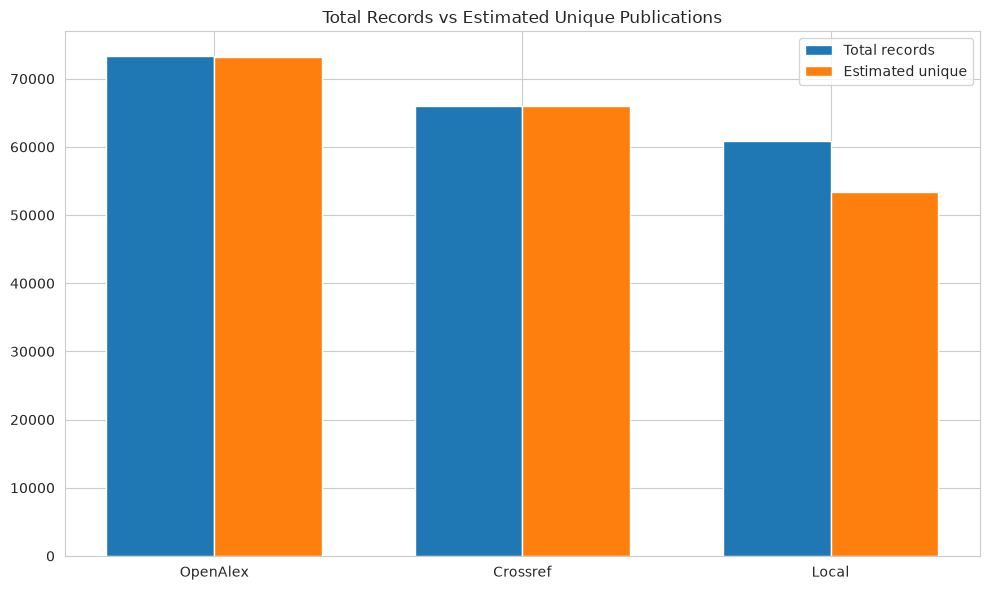

In [22]:
fig, ax = plt.subplots()
plot_df = unique_pub_df.reset_index()
plot_df["total_records"] = pd.to_numeric(plot_df["total_records"])
plot_df["estimated_unique_publications"] = pd.to_numeric(plot_df["estimated_unique_publications"])

x = np.arange(len(plot_df))
width = 0.35
ax.bar(x - width / 2, plot_df["total_records"], width, label="Total records")
ax.bar(x + width / 2, plot_df["estimated_unique_publications"], width, label="Estimated unique")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["dataset"])
ax.set_title("Total Records vs Estimated Unique Publications")
ax.legend()
plt.tight_layout()
plt.show()


## 15. Type × institution heatmap (Local)

Useful to see which repositories hold theses, conference papers, journal articles, etc.


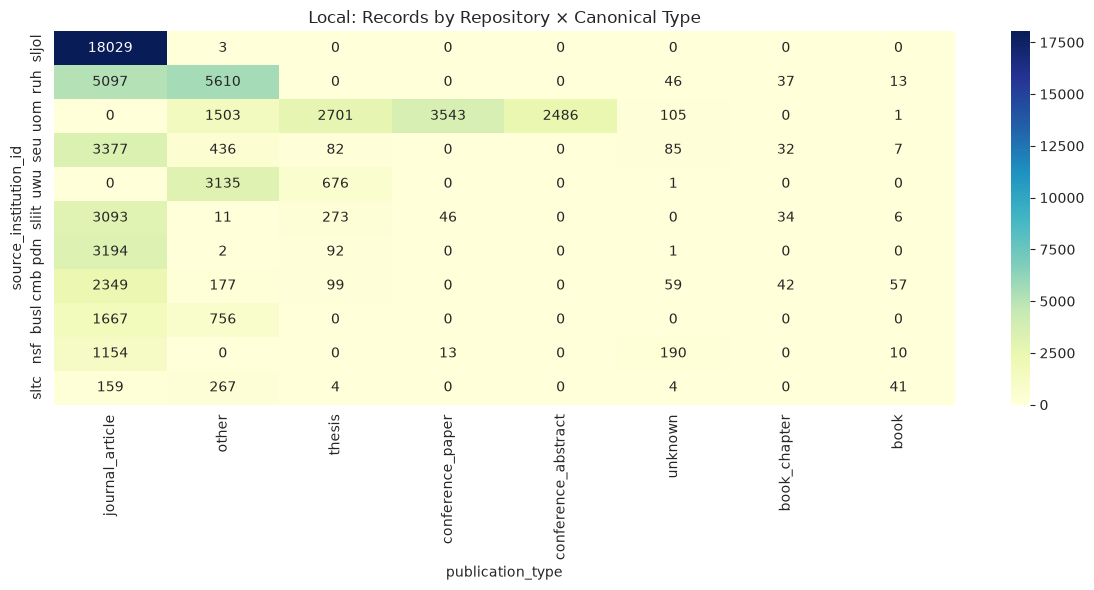

Saved -> outputs/notebook01/10_local_type_by_institution.csv


publication_type,journal_article,other,thesis,conference_paper,conference_abstract,unknown,book_chapter,book
source_institution_id,,,,,,,,
sljol,18029,3,0,0,0,0,0,0
ruh,5097,5610,0,0,0,46,37,13
uom,0,1503,2701,3543,2486,105,0,1
seu,3377,436,82,0,0,85,32,7
uwu,0,3135,676,0,0,1,0,0
sliit,3093,11,273,46,0,0,34,6
pdn,3194,2,92,0,0,1,0,0
cmb,2349,177,99,0,0,59,42,57
busl,1667,756,0,0,0,0,0,0


In [23]:
local_type = get_field("Local", "type").map(canonical_type)
local_inst = get_field("Local", "institution").astype(str)
ct = pd.crosstab(local_inst, local_type)
# keep top institutions and types by volume
top_inst = ct.sum(axis=1).sort_values(ascending=False).head(11).index
top_types = ct.sum(axis=0).sort_values(ascending=False).head(8).index
ct_plot = ct.loc[top_inst, top_types]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ct_plot, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Local: Records by Repository × Canonical Type")
plt.tight_layout()
plt.show()

ct_plot.to_csv(OUTPUT_DIR / "10_local_type_by_institution.csv")
print("Saved ->", OUTPUT_DIR / "10_local_type_by_institution.csv")
ct_plot


## 16. Combined summary


In [24]:
combined_summary = records_summary.set_index("dataset").join([
    year_stats_df,
    doi_avail_df[["non_missing", "coverage_pct"]].rename(columns={
        "non_missing": "doi_non_missing",
        "coverage_pct": "doi_coverage_pct",
    }),
    dup_doi_df[["duplicate_doi_values"]],
    dup_title_df[["duplicate_title_values"]],
    unique_pub_df[["estimated_unique_publications", "estimation_method"]],
])
save_csv(combined_summary, "11_notebook01_combined_summary.csv")
combined_summary


Saved -> outputs/notebook01/11_notebook01_combined_summary.csv


,total_records,total_columns,min_year,max_year,records_2016_plus,records_2016_plus_pct,doi_non_missing,doi_coverage_pct,duplicate_doi_values,duplicate_title_values,estimated_unique_publications,estimation_method
dataset,,,,,,,,,,,,
OpenAlex,73289,34,2016.0,2026.0,73289.0,100.00,71399,97.42,32,2876,73257,unique_doi + no_doi_records
Crossref,65946,55,2016.0,2027.0,65779.0,99.75,65946,100.0,0,1325,65946,unique_doi + no_doi_records
Local,60812,19,2016.0,2099.0,60812.0,100.00,25406,41.78,645,4145,53320,unique_normalized_titles


## 17. Key takeaways — how this informs missing-value handling

Interpret after running:

1. **OpenAlex** is near-complete on DOI (~97%) and is the primary corpus for Sri Lanka works —
   use it as the merge backbone.
2. **Crossref** is DOI-complete by construction (DOI-keyed harvest) — best enrichment partner
   for venue, funding, license, abstract, ORCID, references.
3. **Local** has substantially lower DOI coverage — institute-wise DOI gaps (section 11) show
   where title/author matching is required; SLJOL vs university repos differ strongly.
4. **Type-wise DOI gaps** (section 10): theses / exam papers / grey literature in Local often
   lack DOIs — do not force DOI-only joins for those types.
5. **Duplicates**: dedupe within source before cross-source merge (DOI first, title fallback).
6. Next notebooks:
   - **02** — field completeness matrix + type/institute missingness
   - **03** — which source fills which gaps (enrichment rules)
